# VPN Traffic Obfuscation - Comprehensive Analysis

## Overview
This notebook provides a detailed analysis of VPN traffic obfuscation techniques (Baseline WireGuard, UDP2RAW, OBFS4).
It analyzes data from six key sources:
1. **Metadata**: Run configurations, tool versions, and reproducibility seeds.
2. **Suricata**: Intrusion Detection System (IDS) alerts and signature matches (ET Open ruleset, ~49k rules).
3. **Zeek**: Network Security Monitor (NSM) flow logs and protocol detection.
4. **nDPI**: Deep Packet Inspection — protocol fingerprinting beyond signature matching.
5. **Packet Features**: Low-level packet characteristics (Size, Timing) extracted via Tshark.
6. **Performance**: Throughput metrics from iPerf3.

Additionally, **Shannon Entropy** analysis is performed on raw packet payloads to quantify obfuscation randomness.

### Detection Layers
| Layer | Tool | Method | Question |
|-------|------|--------|----------|
| Signature-based IDS | Suricata (ET Open) | Pattern matching against known signatures | Does the traffic match any known malicious/VPN pattern? |
| Flow Analysis | Zeek | Protocol identification from flow behaviour | Can the application-layer protocol be identified? |
| Deep Packet Inspection | nDPI | Protocol fingerprinting via header/payload heuristics | What protocol does the traffic actually look like? |
| Statistical Analysis | Notebook (scipy, tshark) | Entropy, packet size, IAT distributions | Is the traffic statistically distinguishable from random? |

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import glob
import os
import numpy as np

# Configure Aesthetics
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = [14, 8]
plt.rcParams['font.size'] = 12

RESULTS_DIR = "../results/runs"

def load_runs(base_dir):
    runs_data = []
    
    # Structure: results/runs/<scenario>/<timestamp>/metadata.json
    meta_files = glob.glob(os.path.join(base_dir, "**", "metadata.json"), recursive=True)
    
    # Filter out metadata.json inside subdirectories (e.g. suricata/metadata.json)
    # and exclude validation runs — only keep top-level run metadata
    filtered = []
    for mf in meta_files:
        parent = os.path.basename(os.path.dirname(mf))
        # Skip if parent is a known subdirectory (suricata, zeek, pcap, etc.)
        if parent in ('suricata', 'zeek', 'pcap', 'pcap_features', 'iperf'):
            continue
        # Skip validation runs
        run_path = os.path.dirname(mf)
        if '/validation/' in run_path:
            continue
        filtered.append(mf)
    
    meta_files = filtered
    print(f"Found {len(meta_files)} scenario runs.")
    
    for meta_path in meta_files:
        run_path = os.path.dirname(meta_path)
        
        # 1. Load Metadata
        try:
            with open(meta_path, 'r') as f:
                meta = json.load(f)
        except Exception as e:
            print(f"Skipping {run_path}: Invalid metadata ({e})")
            continue
        
        # Skip runs without a valid scenario
        scenario = meta.get("scenario", "unknown")
        if scenario in ("unknown", "validation"):
            continue
            
        run_data = {
            "id": os.path.basename(run_path),
            "path": run_path,
            "scenario": scenario,
            "mode": meta.get("mode", "unknown"),
            "seed": meta.get("seed", "N/A"),
            "timestamp": meta.get("timestamp", "N/A"),
            "suricata_version": meta.get("versions", {}).get("suricata", "N/A"),
            "zeek_version": meta.get("versions", {}).get("zeek", "N/A"),
            "tshark_version": meta.get("versions", {}).get("tshark", "N/A"),
            "suricata_rules_count": meta.get("loaded_rules_count", 0)
        }
        
        # Load Suricata rules count from suricata subdirectory metadata if available
        suri_meta_path = os.path.join(run_path, "suricata", "metadata.json")
        if os.path.exists(suri_meta_path) and run_data["suricata_rules_count"] == 0:
            try:
                with open(suri_meta_path) as f:
                    suri_meta = json.load(f)
                    run_data["suricata_rules_count"] = suri_meta.get("loaded_rules_count", 0)
            except: pass
        
        # 2. Load Suricata Alerts (EVE JSON)
        eve_path = os.path.join(run_path, "suricata", "eve.json")
        alerts = []
        if os.path.exists(eve_path):
            try:
                with open(eve_path, 'r') as f:
                    for line in f:
                        entry = json.loads(line)
                        if entry.get('event_type') == 'alert':
                            alerts.append(entry.get('alert'))
            except Exception as e: 
                print(f"Error reading eve.json in {run_path}: {e}")
        run_data["alerts"] = pd.DataFrame(alerts)
        
        # 3. Load Zeek Flows (Conn.log JSON)
        conn_path = os.path.join(run_path, "zeek", "conn.log")
        zeek_flows = []
        if os.path.exists(conn_path):
            try:
                with open(conn_path, 'r') as f:
                    first_char = f.read(1)
                
                if first_char == '{':
                    with open(conn_path, 'r') as f:
                        for line in f:
                            try:
                                zeek_flows.append(json.loads(line))
                            except: pass
                    run_data["zeek_df"] = pd.DataFrame(zeek_flows)
                else:
                    run_data["zeek_df"] = pd.read_csv(conn_path, sep="\t", comment="#", on_bad_lines='skip')
            except Exception as e:
                print(f"Error reading zeek conn.log in {run_path}: {e}")
                run_data["zeek_df"] = pd.DataFrame()
        else:
            run_data["zeek_df"] = pd.DataFrame()
            
        # 4. Load Packet Features (CSV)
        packet_path = os.path.join(run_path, "pcap_features", "packets.csv")
        if os.path.exists(packet_path):
            try:
                run_data["packets_df"] = pd.read_csv(packet_path)
                run_data["packets_df"]['frame.len'] = pd.to_numeric(run_data["packets_df"]['frame.len'], errors='coerce')
                run_data["packets_df"]['frame.time_epoch'] = pd.to_numeric(run_data["packets_df"]['frame.time_epoch'], errors='coerce')
            except Exception as e:
                print(f"Error reading packets.csv in {run_path}: {e}")
                run_data["packets_df"] = pd.DataFrame()
        else:
            run_data["packets_df"] = pd.DataFrame()

        # 5. Load Performance (iPerf JSON)
        iperf_path = os.path.join(run_path, "iperf", "iperf.json")
        run_data["throughput_mbps"] = 0.0
        run_data["retransmits"] = 0
        
        if os.path.exists(iperf_path):
            try:
                with open(iperf_path, 'r') as f:
                    iperf_data = json.load(f)
                    end = iperf_data.get('end', {})
                    sum_sent = end.get('sum_sent', {})
                    bps = sum_sent.get('bits_per_second', 0)
                    run_data["throughput_mbps"] = bps / 1e6
                    run_data["retransmits"] = sum_sent.get('retransmits', 0)
            except:
                pass

        runs_data.append(run_data)
        
    return pd.DataFrame(runs_data)

df_runs = load_runs(RESULTS_DIR)

# Enrich Label
if not df_runs.empty:
    df_runs['label'] = df_runs['scenario'] + " (" + df_runs['mode'] + ")"
    
    if 'packets_df' not in df_runs.columns:
        df_runs['packets_df'] = None
    if 'zeek_df' not in df_runs.columns:
        df_runs['zeek_df'] = None

    print(f"Successfully loaded {len(df_runs)} runs.")
    display(df_runs[['id', 'scenario', 'mode', 'timestamp', 'seed', 'suricata_rules_count']].sort_values('timestamp', ascending=False))
else:
    print("No valid runs found. Please execute experiment scripts first.")

Found 6 scenario runs.
Successfully loaded 6 runs.


,id,scenario,mode,timestamp,seed,suricata_rules_count
4,16-03-2026-00-10-50,obfs4,streaming,2026-03-16T00:13:20Z,1773619929,49099
1,15-03-2026-22-39-38,udp2raw,streaming,2026-03-15T22:41:59Z,1773614448,49099
2,15-03-2026-22-36-04,baseline,streaming,2026-03-15T22:38:24Z,1773614235,49099
5,15-03-2026-22-33-43,obfs4,burst,2026-03-15T22:35:53Z,1773614094,49099
0,15-03-2026-22-31-29,udp2raw,burst,2026-03-15T22:33:39Z,1773613959,49099
3,15-03-2026-22-29-33,baseline,burst,2026-03-15T22:31:23Z,1773613820,49099


## 2. IDS Visibility (Suricata & Zeek)
How well do the security tools see the traffic?
- **Suricata Alerts**: Normalized per minute.
- **Zeek Protocol Detection**: Percentage of flows identified as 'unknown' or 'SSL/TLS'.

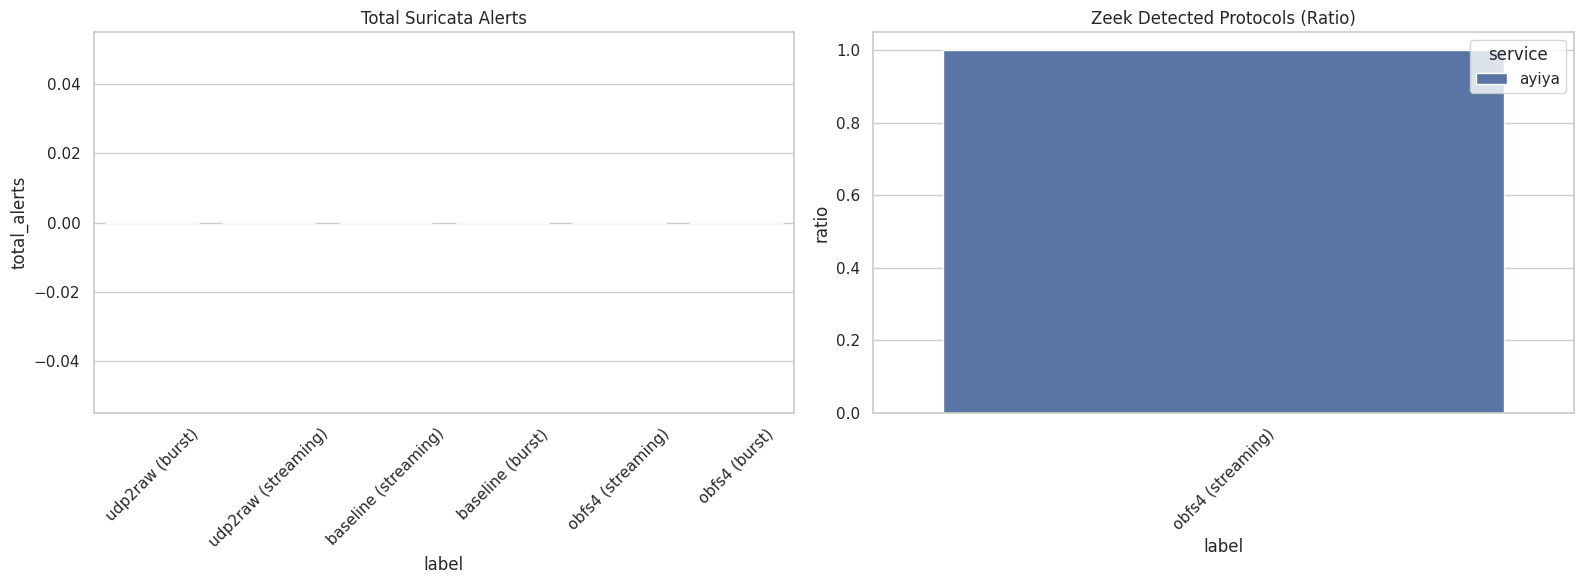

In [2]:
if not df_runs.empty:
    # Aggregate Alerts
    alert_stats = []
    for _, row in df_runs.iterrows():
        alerts_df = row['alerts']
        count = len(alerts_df) if not alerts_df.empty else 0
        
        # Determine duration for normalization
        duration = 60 # Default assumption
        if row['zeek_df'] is not None and not row['zeek_df'].empty:
             # Try to get duration from Zeek logs sum
             try:
                 zeek_durs = pd.to_numeric(row['zeek_df']['duration'], errors='coerce').sum()
                 if zeek_durs > 0: duration = max(duration, zeek_durs)
             except: pass
        
        alert_stats.append({
            'label': row['label'],
            'total_alerts': count,
            'alerts_per_min': (count / duration) * 60
        })
    
    df_alerts = pd.DataFrame(alert_stats)
    
    # Plot
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    
    sns.barplot(data=df_alerts, x='label', y='total_alerts', hue='label', ax=ax[0], palette='viridis')
    ax[0].set_title("Total Suricata Alerts")
    ax[0].tick_params(axis='x', rotation=45)

    # Zeek Protocol Breakdown
    zeek_proto_stats = []
    for _, row in df_runs.iterrows():
        zdf = row['zeek_df']
        if zdf is not None and not zdf.empty and 'service' in zdf.columns:
            # Count services
            # Fill NA or '-' with 'unknown'
            services = zdf['service'].replace('-', 'unknown').fillna('unknown')
            counts = services.value_counts(normalize=True).reset_index()
            counts.columns = ['service', 'ratio']
            counts['label'] = row['label']
            zeek_proto_stats.append(counts)
    
    if zeek_proto_stats:
        df_zeek = pd.concat(zeek_proto_stats)
        sns.barplot(data=df_zeek, x='label', y='ratio', hue='service', ax=ax[1])
        ax[1].set_title("Zeek Detected Protocols (Ratio)")
        ax[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

## 2b. Deep Packet Inspection (nDPI)
nDPI performs protocol fingerprinting by analysing packet headers and payload patterns — going beyond Suricata's signature matching.
Unlike Suricata (which looks for known attack signatures), nDPI tries to **identify what protocol the traffic actually is**.

Key question: Can nDPI correctly identify WireGuard, or does obfuscation successfully disguise it?

In [ ]:
if not df_runs.empty:
    ndpi_results = []
    
    for _, row in df_runs.iterrows():
        run_path = row['path']
        summary_path = os.path.join(run_path, "ndpi", "summary.txt")
        flows_path = os.path.join(run_path, "ndpi", "flows.csv")
        
        ndpi_proto = "N/A"
        ndpi_confidence = "N/A"
        ndpi_category = "N/A"
        total_packets = 0
        total_bytes = 0
        
        # Parse summary.txt
        if os.path.exists(summary_path):
            with open(summary_path) as f:
                content = f.read()
            
            # Extract detected protocol line (first line after "Detected protocols:")
            import re
            proto_match = re.search(r'Detected protocols:\n\t(\S+)\s+packets:\s+(\d+)\s+bytes:\s+(\d+)', content)
            if proto_match:
                ndpi_proto = proto_match.group(1)
                total_packets = int(proto_match.group(2))
                total_bytes = int(proto_match.group(3))
            
            # Extract confidence
            conf_match = re.search(r'Confidence:\s+(\S+)\s+(\d+)', content)
            if conf_match:
                ndpi_confidence = conf_match.group(1)
            
            # Extract protocol category
            cat_match = re.search(r'Protocol statistics:\n\t(\S+)', content)
            if cat_match:
                ndpi_category = cat_match.group(1)
        
        # Parse flows.csv for additional details (ndpiReader uses '|' as delimiter)
        ndpi_server_name = "N/A"
        if os.path.exists(flows_path):
            try:
                fdf = pd.read_csv(flows_path, comment='#', header=0, sep='|')
                if 'server_name_sni' in fdf.columns and not fdf['server_name_sni'].isna().all():
                    ndpi_server_name = fdf['server_name_sni'].dropna().iloc[0] if len(fdf['server_name_sni'].dropna()) > 0 else "N/A"
            except:
                pass
        
        ndpi_results.append({
            'Scenario': row['label'],
            'nDPI Protocol': ndpi_proto,
            'Confidence': ndpi_confidence,
            'Category': ndpi_category,
            'Packets': f"{total_packets:,}",
            'Bytes': f"{total_bytes:,}",
            'WireGuard Detected?': 'Yes' if ndpi_proto == 'WireGuard' else 'No'
        })
    
    df_ndpi = pd.DataFrame(ndpi_results)
    
    # Display table
    print("=" * 90)
    print("nDPI DEEP PACKET INSPECTION RESULTS")
    print("=" * 90)
    print()
    
    display(df_ndpi.style.set_caption(
        "nDPI Protocol Identification per Scenario"
    ).set_properties(**{'text-align': 'center'}).map(
        lambda v: 'background-color: #ffcccc; font-weight: bold' if v == 'Yes' else 
                  ('background-color: #ccffcc; font-weight: bold' if v == 'No' else ''),
        subset=['WireGuard Detected?']
    ))
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Protocol classification bar chart
    proto_colors = {'WireGuard': '#e74c3c', 'TLS': '#f39c12', 'Unknown': '#27ae60'}
    colors = [proto_colors.get(p, '#95a5a6') for p in df_ndpi['nDPI Protocol']]

    axes[0].barh(df_ndpi['Scenario'], [1]*len(df_ndpi), color=colors, edgecolor='white', height=0.6)
    for i, (_, row) in enumerate(df_ndpi.iterrows()):
        axes[0].text(0.5, i, f"{row['nDPI Protocol']}\n({row['Packets']} pkts)", 
                    ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    axes[0].set_xlim(0, 1)
    axes[0].set_xticks([])
    axes[0].set_title("nDPI Protocol Classification per Scenario")
    
    legend_elements = [
        Patch(facecolor='#e74c3c', label='WireGuard (identified)'),
        Patch(facecolor='#f39c12', label='TLS (misclassified)'),
        Patch(facecolor='#27ae60', label='Unknown (obfuscation effective)')
    ]
    axes[0].legend(handles=legend_elements, loc='lower right', fontsize=10)
    
    # Detection success matrix
    detection_map = {'WireGuard': 2, 'TLS': 1, 'Unknown': 0}
    detect_scores = []
    for _, row in df_ndpi.iterrows():
        detect_scores.append({
            'Scenario': row['Scenario'],
            'Score': detection_map.get(row['nDPI Protocol'], 0)
        })
    
    df_scores = pd.DataFrame(detect_scores)
    score_matrix = df_scores.set_index('Scenario')[['Score']]
    score_matrix.columns = ['nDPI\nDetection']
    
    sns.heatmap(score_matrix, annot=df_ndpi.set_index('Scenario')[['nDPI Protocol']].values, 
                fmt='', cmap='RdYlGn_r', linewidths=1, ax=axes[1],
                cbar_kws={'label': '0=Unknown, 1=Misclassified, 2=Identified'},
                vmin=0, vmax=2)
    axes[1].set_title("nDPI Detection Effectiveness")
    
    plt.tight_layout()
    plt.show()
    
    # Interpretation
    print()
    print("Interpretation:")
    for _, row in df_ndpi.iterrows():
        proto = row['nDPI Protocol']
        if proto == 'WireGuard':
            print(f"  ! {row['Scenario']}: WireGuard IDENTIFIED — no obfuscation, protocol headers visible")
        elif proto == 'TLS':
            print(f"  ~ {row['Scenario']}: Classified as TLS — FakeTCP mimics port 443 but lacks real TLS handshake")
        elif proto == 'Unknown':
            print(f"  + {row['Scenario']}: UNKNOWN — obfuscation effective, nDPI cannot identify the protocol")

## 3. Traffic Fingerprinting (Packet-Level)
Analysis of packet sizes and Inter-Arrival Times (IAT) to identify obfuscation patterns.
We separate TCP and UDP traffic.

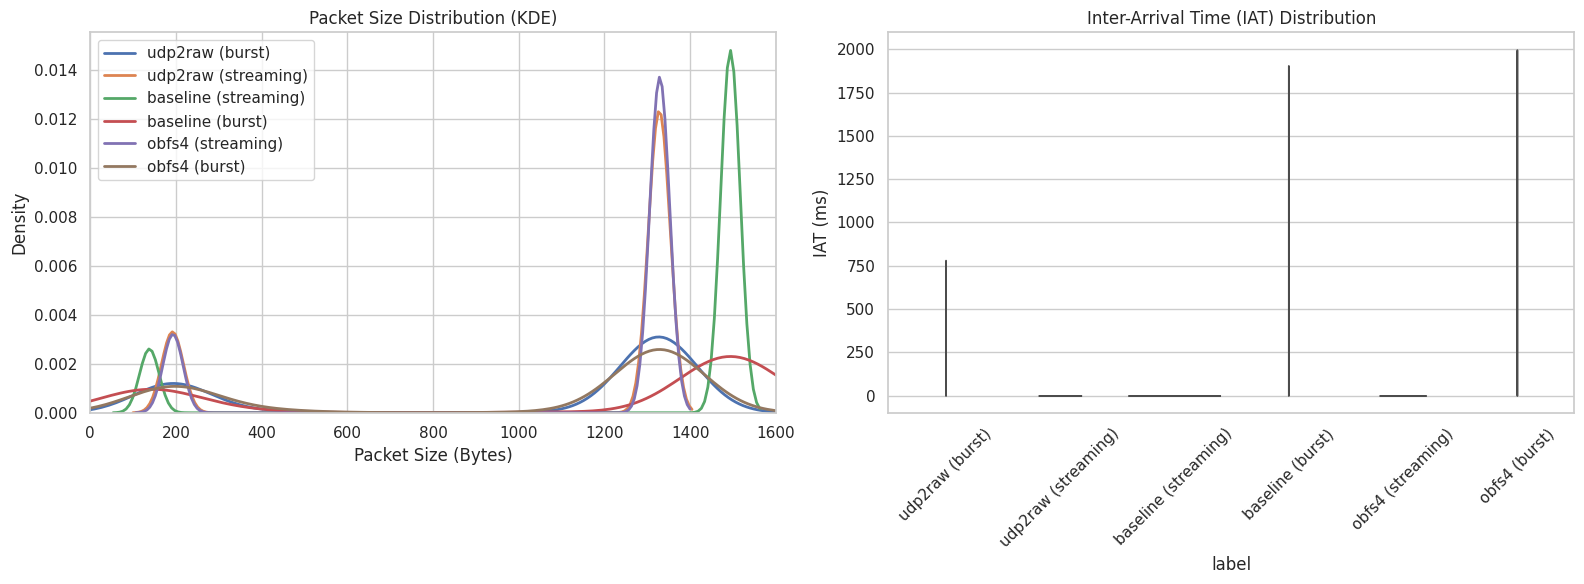

In [4]:
def calculate_iat(df):
    """Calculate Inter-Arrival Times in milliseconds."""
    if df is None or df.empty or 'frame.time_epoch' not in df.columns:
        return pd.Series(dtype=float)
    df_sorted = df.sort_values('frame.time_epoch')
    iat = df_sorted['frame.time_epoch'].diff().dropna()
    iat = iat[iat > 0] * 1000  # Convert to ms
    return iat.reset_index(drop=True)

if not df_runs.empty:
    # Filter only runs with packet data
    valid_runs = df_runs[df_runs['packets_df'].apply(lambda x: x is not None and not x.empty)]
    
    if not valid_runs.empty:
        # PACKET SIZES
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        for _, row in valid_runs.iterrows():
            pdf = row['packets_df']
            if pdf.empty: continue
            sns.kdeplot(pdf['frame.len'], label=row['label'], fill=False, linewidth=2, ax=axes[0])
        
        axes[0].set_title("Packet Size Distribution (KDE)")
        axes[0].set_xlabel("Packet Size (Bytes)")
        axes[0].set_xlim(0, 1600)
        axes[0].legend()
        
        # IAT Analysis (Violin Plot — more informative than boxplot)
        iat_data = []
        for _, row in valid_runs.iterrows():
            pdf = row['packets_df']
            if pdf.empty: continue
            
            iat = calculate_iat(pdf)
            if len(iat) == 0: continue
            # Downsample for plotting if huge
            if len(iat) > 2000:
                iat = iat.sample(2000, random_state=42)
            
            temp_df = pd.DataFrame({'iat_ms': iat})
            temp_df['label'] = row['label']
            iat_data.append(temp_df)
            
        if iat_data:
            df_iat = pd.concat(iat_data)
            sns.violinplot(data=df_iat, x='label', y='iat_ms', inner='quartile',
                          cut=0, ax=axes[1])
            axes[1].set_title("Inter-Arrival Time (IAT) Distribution")
            axes[1].set_ylabel("IAT (ms)")
            axes[1].tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()

## 4. Protocol Plausibility Check
Does traffic on TCP/443 actually look like TLS? 
We check for `tls.handshake.type == 1` (Client Hello) in flows on port 443.

In [5]:
if not df_runs.empty:
    plausibility_stats = []
    
    for _, row in valid_runs.iterrows():
        pdf = row['packets_df']
        if pdf.empty: continue
        
        # Work on a copy
        pdf_tmp = pdf.copy()
        
        # Check for TCP destination port column
        has_tcp = 'tcp.dstport' in pdf_tmp.columns
        has_tls = 'tls.handshake.type' in pdf_tmp.columns
        
        if has_tcp:
            pdf_tmp['tcp.dstport'] = pd.to_numeric(pdf_tmp['tcp.dstport'], errors='coerce')
            total_443 = len(pdf_tmp[pdf_tmp['tcp.dstport'] == 443])
        else:
            total_443 = 0
        
        # Count TLS Client Hellos
        client_hellos = 0
        if has_tls and total_443 > 0:
            https_packets = pdf_tmp[pdf_tmp['tcp.dstport'] == 443]
            client_hellos = len(https_packets[https_packets['tls.handshake.type'] == 1])
        
        # Determine transport protocol from Zeek
        zdf = row['zeek_df']
        transport = "N/A"
        port = "N/A"
        if zdf is not None and not zdf.empty:
            transport = zdf['proto'].iloc[0] if 'proto' in zdf.columns else "N/A"
            port = str(zdf['id.resp_p'].iloc[0]) if 'id.resp_p' in zdf.columns else "N/A"
        
        plausibility_stats.append({
            'Scenario': row['label'],
            'Transport': f"{transport.upper()}/{port}",
            'Total Packets': len(pdf_tmp),
            'Packets on 443': total_443,
            'TLS Client Hellos': client_hellos,
            'TLS Hello Ratio': f"{client_hellos}/{total_443}" if total_443 > 0 else "N/A (no TCP/443)",
            'Plausible TLS?': "No" if total_443 > 0 and client_hellos == 0 else ("N/A" if total_443 == 0 else "Yes")
        })
    
    if plausibility_stats:
        df_plaus = pd.DataFrame(plausibility_stats)
        
        print("=" * 90)
        print("PROTOCOL PLAUSIBILITY CHECK — Does TCP/443 traffic contain real TLS?")
        print("=" * 90)
        print()
        display(df_plaus.style.set_caption(
            "Protocol Plausibility: TLS Client Hello detection on port 443"
        ).set_properties(**{'text-align': 'center'}).map(
            lambda v: 'background-color: #ffcccc' if v == 'No' else 
                      ('background-color: #ccffcc' if v == 'Yes' else ''),
            subset=['Plausible TLS?']
        ))
        
        print()
        print("Interpretation:")
        for _, row in df_plaus.iterrows():
            if row['Packets on 443'] > 0 and row['TLS Client Hellos'] == 0:
                print(f"  ! {row['Scenario']}: {row['Packets on 443']} packets on TCP/443 but "
                      f"0 TLS Client Hellos -> FakeTCP detected by DPI")
            elif row['Packets on 443'] == 0:
                print(f"  - {row['Scenario']}: No TCP/443 traffic (uses {row['Transport']})")
    else:
        print("No packet data available for plausibility analysis.")

PROTOCOL PLAUSIBILITY CHECK — Does TCP/443 traffic contain real TLS?



,Scenario,Transport,Total Packets,Packets on 443,TLS Client Hellos,TLS Hello Ratio,Plausible TLS?
0,udp2raw (burst),TCP/443,5596,1616,0,0/1616,No
1,udp2raw (streaming),TCP/443,2006012,1582043,0,0/1582043,No
2,baseline (streaming),UDP/51820,4233888,0,0,N/A (no TCP/443),N/A
3,baseline (burst),UDP/51820,3790,0,0,N/A (no TCP/443),N/A
4,obfs4 (streaming),UDP/12345,2416267,0,0,N/A (no TCP/443),N/A
5,obfs4 (burst),UDP/12345,2937,0,0,N/A (no TCP/443),N/A



Interpretation:
  ! udp2raw (burst): 1616 packets on TCP/443 but 0 TLS Client Hellos -> FakeTCP detected by DPI
  ! udp2raw (streaming): 1582043 packets on TCP/443 but 0 TLS Client Hellos -> FakeTCP detected by DPI
  - baseline (streaming): No TCP/443 traffic (uses UDP/51820)
  - baseline (burst): No TCP/443 traffic (uses UDP/51820)
  - obfs4 (streaming): No TCP/443 traffic (uses UDP/12345)
  - obfs4 (burst): No TCP/443 traffic (uses UDP/12345)


## 5. Performance Impact
Throughput comparison and relative overhead.

/tmp/ipykernel_2393/4069221348.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=perf_df, x='label', y='throughput_mbps', ax=ax[0], palette='coolwarm')
/tmp/ipykernel_2393/4069221348.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=perf_df, x='label', y='overhead_pct', ax=ax[1], palette='Reds')


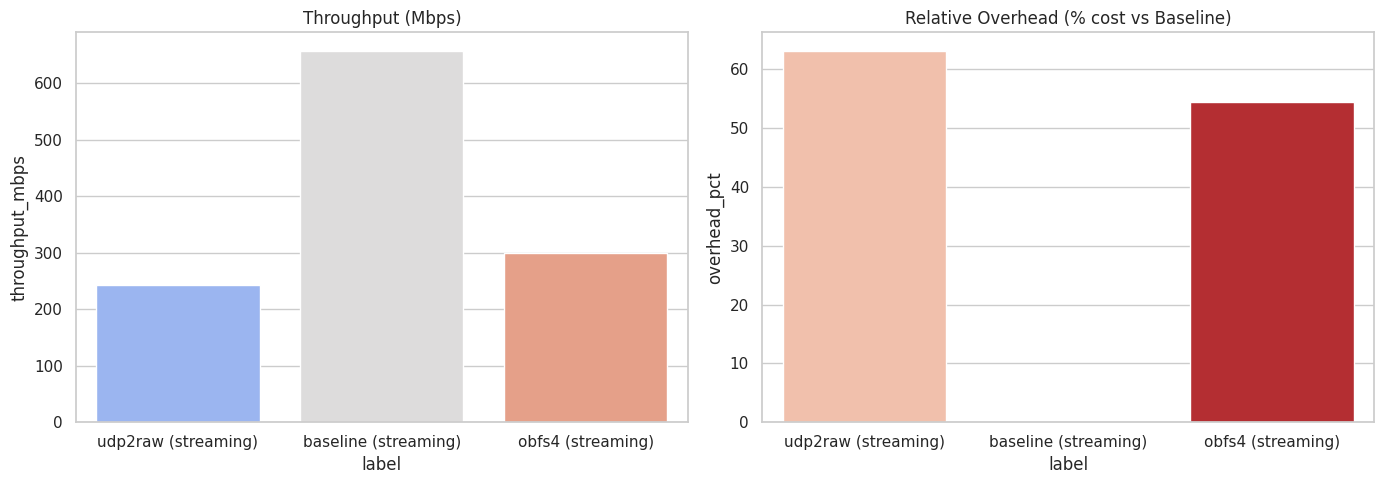

In [6]:
if not df_runs.empty:
    # Filter Streaming modes usually have valid iperf data
    perf_df = df_runs[(df_runs['throughput_mbps'] > 0)].copy()
    
    if not perf_df.empty:
        # Calculate Overhead vs Baseline
        # Find baseline throughput
        baseline_row = perf_df[perf_df['scenario'] == 'baseline']
        if not baseline_row.empty:
            base_tp = baseline_row['throughput_mbps'].mean()
            perf_df['overhead_pct'] = ((base_tp - perf_df['throughput_mbps']) / base_tp) * 100
        else:
            perf_df['overhead_pct'] = 0
            
        fig, ax = plt.subplots(1, 2, figsize=(14, 5))
        
        sns.barplot(data=perf_df, x='label', y='throughput_mbps', ax=ax[0], palette='coolwarm')
        ax[0].set_title("Throughput (Mbps)")
        
        sns.barplot(data=perf_df, x='label', y='overhead_pct', ax=ax[1], palette='Reds')
        ax[1].set_title("Relative Overhead (% cost vs Baseline)")
        
        plt.tight_layout()
        plt.show()
    else:
        print("No valid iPerf3 throughput data found (did you run 'streaming' mode?)")

## 6. Shannon Entropy Analysis
Entropy measures the randomness of packet payloads. Higher entropy indicates more effective obfuscation.
- **Baseline WireGuard**: Encrypted but with recognisable headers (Type 1-4, Reserved field) → slightly lower entropy.
- **UDP2RAW**: XOR-cipher wrapping → moderate entropy.
- **OBFS4**: Randomised padding + ChaCha20 encryption → expected near-maximum entropy.

We approximate payload entropy from packet sizes and byte distributions captured in the PCAP features.

Computing entropy for udp2raw (burst) (wg-udp2raw.pcap)...
  -> 3000 packets, mean entropy: 7.379 bits
Computing entropy for udp2raw (streaming) (wg-udp2raw.pcap)...
  -> 3000 packets, mean entropy: 7.525 bits
Computing entropy for baseline (streaming) (wg-baseline.pcap)...
  -> 3000 packets, mean entropy: 7.376 bits
Computing entropy for baseline (burst) (wg-baseline.pcap)...
  -> 3000 packets, mean entropy: 7.329 bits
Computing entropy for obfs4 (streaming) (wg-obfs4.pcap)...
  -> 3000 packets, mean entropy: 7.590 bits
Computing entropy for obfs4 (burst) (wg-obfs4.pcap)...
  -> 2937 packets, mean entropy: 7.522 bits


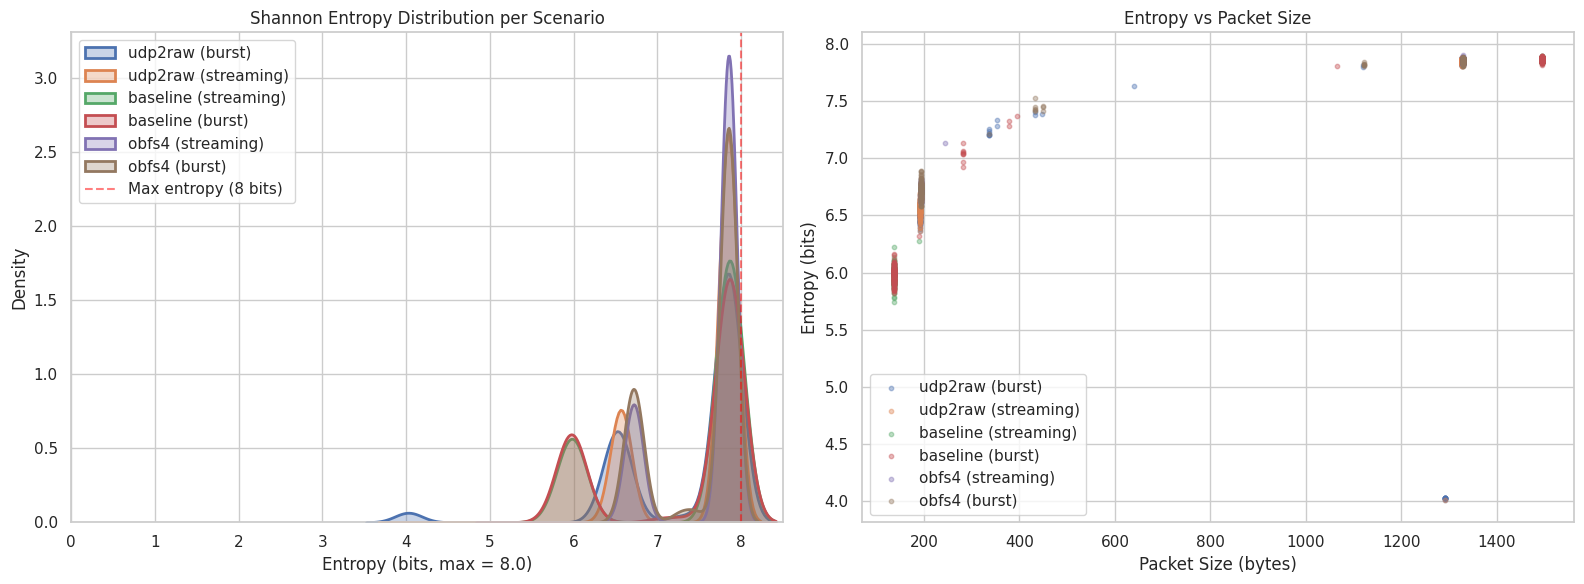

In [7]:
import subprocess, tempfile, struct, math
from collections import Counter

def entropy_from_pcap(pcap_path, max_packets=2000):
    """Extract raw payload bytes from a PCAP and compute per-packet Shannon entropy.
    
    Tries multiple tshark fields because different protocols expose payload differently:
    - data.data: works for unknown/unrecognised protocols (e.g. OBFS4 on UDP)
    - udp.payload: works for UDP-based protocols (e.g. WireGuard)
    - tcp.payload: works for TCP-based protocols (e.g. UDP2RAW wrapping)
    """
    # Try payload fields in order of specificity
    payload_fields = ["data.data", "udp.payload", "tcp.payload"]
    
    best_entropies = []
    best_sizes = []
    
    for field in payload_fields:
        cmd = [
            "tshark", "-r", pcap_path, "-T", "fields",
            "-e", field,
            "-e", "frame.len",
            "-c", str(max_packets)
        ]
        result = subprocess.run(cmd, capture_output=True, text=True, timeout=60)
        
        entropies = []
        sizes = []
        for line in result.stdout.strip().split("\n"):
            if not line.strip():
                continue
            parts = line.split("\t")
            hex_payload = parts[0] if len(parts) > 0 else ""
            frame_len = int(parts[1]) if len(parts) > 1 and parts[1] else 0
            
            if not hex_payload or len(hex_payload) < 4:
                continue
            
            try:
                raw = bytes.fromhex(hex_payload.replace(":", ""))
            except ValueError:
                continue
            
            if len(raw) == 0:
                continue
            
            counts = Counter(raw)
            length = len(raw)
            ent = -sum((c / length) * math.log2(c / length) for c in counts.values())
            entropies.append(ent)
            sizes.append(frame_len)
        
        # Keep the field that extracted the most payloads
        if len(entropies) > len(best_entropies):
            best_entropies = entropies
            best_sizes = sizes
    
    return best_entropies, best_sizes

# Compute entropy for all runs
if not df_runs.empty:
    entropy_data = []
    
    for _, row in df_runs.iterrows():
        run_path = row['path']
        pcap_dir = os.path.join(run_path, "pcap")
        
        if not os.path.isdir(pcap_dir):
            continue
        
        pcap_files = glob.glob(os.path.join(pcap_dir, "*.pcap"))
        if not pcap_files:
            continue
        
        pcap_path = pcap_files[0]
        print(f"Computing entropy for {row['label']} ({os.path.basename(pcap_path)})...")
        
        ents, szs = entropy_from_pcap(pcap_path, max_packets=3000)
        
        if ents:
            temp = pd.DataFrame({
                "entropy": ents,
                "frame_len": szs[:len(ents)],
                "label": row['label'],
                "scenario": row['scenario'],
                "mode": row['mode']
            })
            entropy_data.append(temp)
            print(f"  -> {len(ents)} packets, mean entropy: {np.mean(ents):.3f} bits")
        else:
            print(f"  -> No payload data extracted")
    
    if entropy_data:
        df_entropy = pd.concat(entropy_data, ignore_index=True)
        
        # --- Plot 1: Entropy Distribution (KDE) ---
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        for label in df_entropy['label'].unique():
            subset = df_entropy[df_entropy['label'] == label]
            sns.kdeplot(subset['entropy'], label=label, fill=True, alpha=0.3, ax=axes[0], linewidth=2)
        
        axes[0].set_title("Shannon Entropy Distribution per Scenario")
        axes[0].set_xlabel("Entropy (bits, max = 8.0)")
        axes[0].set_ylabel("Density")
        axes[0].axvline(x=8.0, color='red', linestyle='--', alpha=0.5, label='Max entropy (8 bits)')
        axes[0].legend()
        axes[0].set_xlim(0, 8.5)
        
        # --- Plot 2: Entropy vs Packet Size (Scatter) ---
        for label in df_entropy['label'].unique():
            subset = df_entropy[df_entropy['label'] == label]
            if len(subset) > 500:
                subset = subset.sample(500, random_state=42)
            axes[1].scatter(subset['frame_len'], subset['entropy'], label=label, alpha=0.4, s=10)
        
        axes[1].set_title("Entropy vs Packet Size")
        axes[1].set_xlabel("Packet Size (bytes)")
        axes[1].set_ylabel("Entropy (bits)")
        axes[1].legend()
        
        plt.tight_layout()
        plt.show()
    else:
        print("No entropy data could be extracted. Check tshark availability.")

## 7. Descriptive Statistics & Statistical Tests
Quantitative comparison of packet characteristics across all three scenarios.

- **Descriptive Statistics**: Mean, median, standard deviation, min/max for packet sizes and IAT.
- **Kolmogorov-Smirnov Test**: Pairwise comparison of packet size distributions to quantify how different the scenarios are from each other (p < 0.05 → significantly different distributions).
- **Entropy Statistics**: Per-scenario entropy summary.

In [8]:
from scipy import stats
from itertools import combinations

if not df_runs.empty:
    valid_runs = df_runs[df_runs['packets_df'].apply(lambda x: x is not None and not x.empty)]
    
    # ── 7a. Descriptive Statistics: Packet Size ──────────────────────
    print("=" * 80)
    print("7a. PACKET SIZE DESCRIPTIVE STATISTICS")
    print("=" * 80)
    
    pkt_stats = []
    for _, row in valid_runs.iterrows():
        pdf = row['packets_df']
        sizes = pdf['frame.len'].dropna()
        pkt_stats.append({
            'Scenario': row['label'],
            'Count': len(sizes),
            'Mean (B)': f"{sizes.mean():.1f}",
            'Median (B)': f"{sizes.median():.1f}",
            'Std Dev (B)': f"{sizes.std():.1f}",
            'Min (B)': f"{sizes.min():.0f}",
            'Max (B)': f"{sizes.max():.0f}",
            'IQR (B)': f"{sizes.quantile(0.75) - sizes.quantile(0.25):.1f}"
        })
    
    df_pkt_stats = pd.DataFrame(pkt_stats)
    display(df_pkt_stats.style.set_caption("Packet Size Statistics per Scenario"))
    
    # ── 7b. Descriptive Statistics: Inter-Arrival Time ───────────────
    print("\n" + "=" * 80)
    print("7b. INTER-ARRIVAL TIME (IAT) DESCRIPTIVE STATISTICS")
    print("=" * 80)
    
    iat_stats = []
    iat_per_scenario = {}
    for _, row in valid_runs.iterrows():
        pdf = row['packets_df']
        iat = calculate_iat(pdf)
        if len(iat) == 0:
            continue
        iat_per_scenario[row['label']] = iat.values
        iat_stats.append({
            'Scenario': row['label'],
            'Count': len(iat),
            'Mean (ms)': f"{iat.mean():.4f}",
            'Median (ms)': f"{iat.median():.4f}",
            'Std Dev (ms)': f"{iat.std():.4f}",
            'P95 (ms)': f"{iat.quantile(0.95):.4f}",
            'P99 (ms)': f"{iat.quantile(0.99):.4f}"
        })
    
    df_iat_stats = pd.DataFrame(iat_stats)
    display(df_iat_stats.style.set_caption("IAT Statistics per Scenario"))
    
    # ── 7c. Entropy Statistics ───────────────────────────────────────
    if 'df_entropy' in dir() and not df_entropy.empty:
        print("\n" + "=" * 80)
        print("7c. SHANNON ENTROPY DESCRIPTIVE STATISTICS")
        print("=" * 80)
        
        ent_stats = df_entropy.groupby('label')['entropy'].agg(
            Count='count',
            Mean='mean',
            Median='median',
            Std='std',
            Min='min',
            Max='max'
        ).round(4).reset_index()
        ent_stats.columns = ['Scenario', 'Count', 'Mean (bits)', 'Median (bits)', 
                             'Std Dev', 'Min', 'Max']
        display(ent_stats.style.set_caption("Shannon Entropy Statistics per Scenario"))
    
    # ── 7d. Kolmogorov-Smirnov Tests (Packet Size) ──────────────────
    print("\n" + "=" * 80)
    print("7d. KOLMOGOROV-SMIRNOV TESTS: PACKET SIZE DISTRIBUTIONS")
    print("=" * 80)
    
    # Collect packet sizes per label
    sizes_per_label = {}
    for _, row in valid_runs.iterrows():
        pdf = row['packets_df']
        sizes = pdf['frame.len'].dropna().values
        # Subsample large datasets for KS test efficiency
        if len(sizes) > 10000:
            rng = np.random.default_rng(42)
            sizes = rng.choice(sizes, 10000, replace=False)
        sizes_per_label[row['label']] = sizes
    
    ks_results = []
    labels = list(sizes_per_label.keys())
    for a, b in combinations(labels, 2):
        stat, pval = stats.ks_2samp(sizes_per_label[a], sizes_per_label[b])
        ks_results.append({
            'Comparison': f"{a}  vs  {b}",
            'KS Statistic': f"{stat:.4f}",
            'p-value': f"{pval:.2e}",
            'Significant (p<0.05)': "Yes" if pval < 0.05 else "No"
        })
    
    df_ks = pd.DataFrame(ks_results)
    display(df_ks.style.set_caption("KS Test: Pairwise Packet Size Distribution Comparison"))
    
    # ── 7e. Kolmogorov-Smirnov Tests (IAT) ──────────────────────────
    if iat_per_scenario:
        print("\n" + "=" * 80)
        print("7e. KOLMOGOROV-SMIRNOV TESTS: IAT DISTRIBUTIONS")
        print("=" * 80)
        
        # Subsample IAT for efficiency
        iat_sampled = {}
        for label, vals in iat_per_scenario.items():
            if len(vals) > 10000:
                rng = np.random.default_rng(42)
                vals = rng.choice(vals, 10000, replace=False)
            iat_sampled[label] = vals
        
        ks_iat_results = []
        iat_labels = list(iat_sampled.keys())
        for a, b in combinations(iat_labels, 2):
            stat, pval = stats.ks_2samp(iat_sampled[a], iat_sampled[b])
            ks_iat_results.append({
                'Comparison': f"{a}  vs  {b}",
                'KS Statistic': f"{stat:.4f}",
                'p-value': f"{pval:.2e}",
                'Significant (p<0.05)': "Yes" if pval < 0.05 else "No"
            })
        
        df_ks_iat = pd.DataFrame(ks_iat_results)
        display(df_ks_iat.style.set_caption("KS Test: Pairwise IAT Distribution Comparison"))

7a. PACKET SIZE DESCRIPTIVE STATISTICS


,Scenario,Count,Mean (B),Median (B),Std Dev (B),Min (B),Max (B),IQR (B)
0,udp2raw (burst),5596,1001.8,1328.0,508.1,188,1328,1136.0
1,udp2raw (streaming),2006012,1087.9,1328.0,463.8,176,1328,0.0
2,baseline (streaming),4233888,1290.7,1494.0,484.1,122,1494,0.0
3,baseline (burst),3790,1080.3,1494.0,615.4,134,1494,1356.0
4,obfs4 (streaming),2416267,1113.6,1329.0,445.3,177,1329,0.0
5,obfs4 (burst),2937,980.2,1329.0,514.7,189,1329,1136.0



7b. INTER-ARRIVAL TIME (IAT) DESCRIPTIVE STATISTICS


,Scenario,Count,Mean (ms),Median (ms),Std Dev (ms),P95 (ms),P99 (ms)
0,udp2raw (burst),5589,9.1643,0.0050,73.0675,0.5016,419.5089
1,udp2raw (streaming),1994516,0.0313,0.0050,0.8725,0.1671,0.2789
2,baseline (streaming),4190038,0.0143,0.0088,0.0140,0.0291,0.0701
3,baseline (burst),3732,14.1847,0.0081,139.4559,0.0938,604.3764
4,obfs4 (streaming),2399919,0.0250,0.0050,0.0579,0.1302,0.2859
5,obfs4 (burst),2931,16.6366,0.0050,147.5269,0.4525,703.9324



7c. SHANNON ENTROPY DESCRIPTIVE STATISTICS


,Scenario,Count,Mean (bits),Median (bits),Std Dev,Min,Max
0,baseline (burst),3000,7.328600,7.857700,0.842500,5.346200,7.903500
1,baseline (streaming),3000,7.375900,7.858800,0.826400,5.420700,7.897400
2,obfs4 (burst),2937,7.521600,7.842100,0.504800,6.493200,7.887800
3,obfs4 (streaming),3000,7.590300,7.846400,0.478300,6.499700,7.905500
4,udp2raw (burst),3000,7.379000,7.837500,0.799600,4.007500,7.886700
5,udp2raw (streaming),3000,7.525100,7.840900,0.562800,4.012300,7.890300



7d. KOLMOGOROV-SMIRNOV TESTS: PACKET SIZE DISTRIBUTIONS


,Comparison,KS Statistic,p-value,Significant (p<0.05)
0,udp2raw (burst) vs udp2raw (streaming),0.1136,9.31e-41,Yes
1,udp2raw (burst) vs baseline (streaming),0.8482,0.00e+00,Yes
2,udp2raw (burst) vs baseline (burst),0.6834,0.00e+00,Yes
3,udp2raw (burst) vs obfs4 (streaming),0.8123,0.00e+00,Yes
4,udp2raw (burst) vs obfs4 (burst),0.6745,0.00e+00,Yes
5,udp2raw (streaming) vs baseline (streaming),0.8482,0.00e+00,Yes
6,udp2raw (streaming) vs baseline (burst),0.6834,1.27e-321,Yes
7,udp2raw (streaming) vs obfs4 (streaming),0.8123,0.00e+00,Yes
8,udp2raw (streaming) vs obfs4 (burst),0.6745,2.59e-321,Yes
9,baseline (streaming) vs baseline (burst),0.1648,1.20e-65,Yes



7e. KOLMOGOROV-SMIRNOV TESTS: IAT DISTRIBUTIONS


,Comparison,KS Statistic,p-value,Significant (p<0.05)
0,udp2raw (burst) vs udp2raw (streaming),0.1164,9.73e-43,Yes
1,udp2raw (burst) vs baseline (streaming),0.2629,2.14e-218,Yes
2,udp2raw (burst) vs baseline (burst),0.2776,2.88e-152,Yes
3,udp2raw (burst) vs obfs4 (streaming),0.2179,1.30e-149,Yes
4,udp2raw (burst) vs obfs4 (burst),0.0542,2.33e-05,Yes
5,udp2raw (streaming) vs baseline (streaming),0.2587,2.14e-294,Yes
6,udp2raw (streaming) vs baseline (burst),0.2942,3.68e-208,Yes
7,udp2raw (streaming) vs obfs4 (streaming),0.3343,0.00e+00,Yes
8,udp2raw (streaming) vs obfs4 (burst),0.1706,4.28e-58,Yes
9,baseline (streaming) vs baseline (burst),0.0938,2.88e-21,Yes


## 8. Summary Table — Scenario × Metric
Consolidated results matrix mapping each scenario against all measured detection and fingerprinting metrics. This table is designed for direct inclusion in the thesis evaluation chapter.

COMPREHENSIVE SUMMARY TABLE — Scenario x Metric


,Scenario,Suricata Alerts,nDPI Protocol,Zeek Service-ID,Mean Pkt Size (B),Median Pkt Size (B),Pkt Size Std Dev,Mean IAT (ms),TLS Hello / Port 443,Mean Entropy (bits),Throughput (Mbps),Retransmits
0,udp2raw (burst),0,TLS,N/A,1001.8,1328.0,508.1,9.1643,0/1616,7.379,N/A (burst),0
1,udp2raw (streaming),0,TLS,N/A,1087.9,1328.0,463.8,0.0313,0/1582043,7.525,242.2,223
2,baseline (streaming),0,WireGuard,N/A,1290.7,1494.0,484.1,0.0143,N/A,7.376,656.7,14
3,baseline (burst),0,WireGuard,N/A,1080.3,1494.0,615.4,14.1847,N/A,7.329,N/A (burst),0
4,obfs4 (streaming),0,Unknown,ayiya,1113.6,1329.0,445.3,0.0250,N/A,7.590,299.8,2285
5,obfs4 (burst),0,Unknown,N/A,980.2,1329.0,514.7,16.6366,N/A,7.522,N/A (burst),0




CONDENSED COMPARISON (Burst Mode Only)


Scenario,udp2raw (burst),baseline (burst),obfs4 (burst)
Suricata Alerts,0,0,0
nDPI Protocol,TLS,WireGuard,Unknown
Zeek Service-ID,N/A,N/A,N/A
Mean Pkt Size (B),1001.8,1080.3,980.2
Median Pkt Size (B),1328.0,1494.0,1329.0
Pkt Size Std Dev,508.1,615.4,514.7
Mean IAT (ms),9.1643,14.1847,16.6366
TLS Hello / Port 443,0/1616,N/A,N/A
Mean Entropy (bits),7.379,7.329,7.522
Throughput (Mbps),N/A (burst),N/A (burst),N/A (burst)


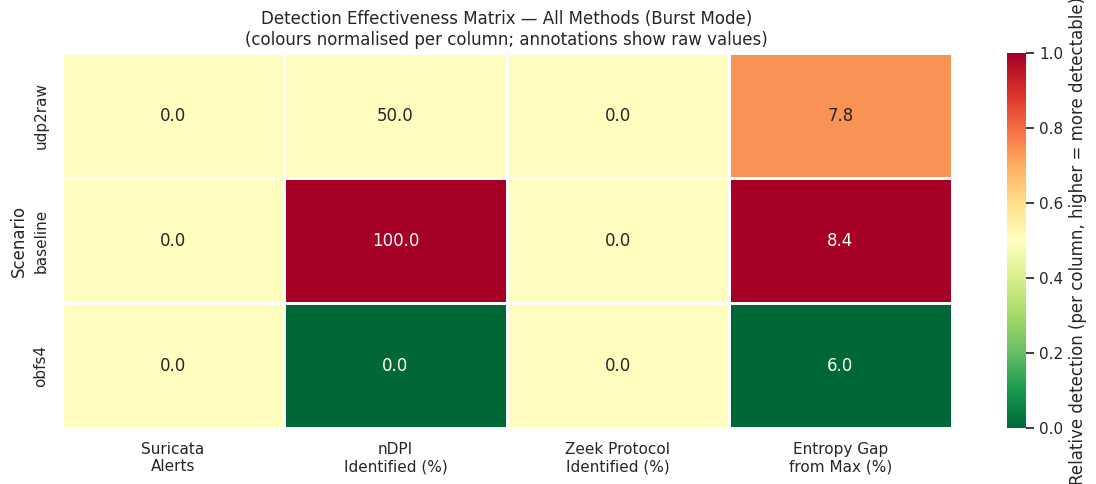

In [9]:
if not df_runs.empty:
    valid_runs = df_runs[df_runs['packets_df'].apply(lambda x: x is not None and not x.empty)]
    
    summary_rows = []
    
    for _, row in valid_runs.iterrows():
        pdf = row['packets_df']
        sizes = pdf['frame.len'].dropna()
        iat = calculate_iat(pdf)
        
        # Suricata alerts
        alerts_df = row['alerts']
        alert_count = len(alerts_df) if not alerts_df.empty else 0
        alert_sigs = ", ".join(alerts_df['signature'].unique()) if not alerts_df.empty else "None"
        
        # Zeek service detection
        zdf = row['zeek_df']
        if zdf is not None and not zdf.empty and 'service' in zdf.columns:
            services = zdf['service'].replace('-', 'unknown').fillna('unknown')
            top_service = services.value_counts().index[0]
        else:
            top_service = "N/A"
        
        # nDPI protocol
        ndpi_proto = "N/A"
        summary_path = os.path.join(row['path'], "ndpi", "summary.txt")
        if os.path.exists(summary_path):
            import re
            with open(summary_path) as f:
                match = re.search(r'Detected protocols:\n\t(\S+)', f.read())
                if match:
                    ndpi_proto = match.group(1)
        
        # TLS Client Hello check
        tls_hello_count = 0
        total_443 = 0
        if 'tls.handshake.type' in pdf.columns and 'tcp.dstport' in pdf.columns:
            pdf_tmp = pdf.copy()
            pdf_tmp['tcp.dstport'] = pd.to_numeric(pdf_tmp['tcp.dstport'], errors='coerce')
            https_pkts = pdf_tmp[pdf_tmp['tcp.dstport'] == 443]
            total_443 = len(https_pkts)
            if total_443 > 0:
                tls_hello_count = len(https_pkts[https_pkts['tls.handshake.type'] == 1])
        
        # Entropy
        mean_entropy = "N/A"
        if 'df_entropy' in dir() and not df_entropy.empty:
            ent_subset = df_entropy[df_entropy['label'] == row['label']]
            if not ent_subset.empty:
                mean_entropy = f"{ent_subset['entropy'].mean():.3f}"
        
        # Throughput
        throughput = f"{row['throughput_mbps']:.1f}" if row['throughput_mbps'] > 0 else "N/A (burst)"
        
        summary_rows.append({
            'Scenario': row['label'],
            'Suricata Alerts': alert_count,
            'nDPI Protocol': ndpi_proto,
            'Zeek Service-ID': top_service,
            'Mean Pkt Size (B)': f"{sizes.mean():.1f}",
            'Median Pkt Size (B)': f"{sizes.median():.1f}",
            'Pkt Size Std Dev': f"{sizes.std():.1f}",
            'Mean IAT (ms)': f"{iat.mean():.4f}" if len(iat) > 0 else "N/A",
            'TLS Hello / Port 443': f"{tls_hello_count}/{total_443}" if total_443 > 0 else "N/A",
            'Mean Entropy (bits)': mean_entropy,
            'Throughput (Mbps)': throughput,
            'Retransmits': row.get('retransmits', 'N/A')
        })
    
    df_summary = pd.DataFrame(summary_rows)
    
    # Display full summary
    print("=" * 100)
    print("COMPREHENSIVE SUMMARY TABLE — Scenario x Metric")
    print("=" * 100)
    display(df_summary.style.set_caption(
        "Summary: All metrics across all scenarios and traffic modes"
    ).set_properties(**{'text-align': 'center'}))
    
    # ── Condensed comparison table (burst mode only) ─────────────────
    print("\n")
    print("=" * 100)
    print("CONDENSED COMPARISON (Burst Mode Only)")
    print("=" * 100)
    
    burst_summary = df_summary[df_summary['Scenario'].str.contains('burst')]
    if not burst_summary.empty:
        burst_t = burst_summary.set_index('Scenario').T
        display(burst_t.style.set_caption(
            "Burst Mode: Side-by-Side Scenario Comparison"
        ))
    
    # ── Detection Effectiveness Heatmap (per-column normalisation) ───
    print("\n")
    
    burst_runs = valid_runs[valid_runs['mode'] == 'burst']
    detect_data = []
    for _, row in burst_runs.iterrows():
        alerts_df = row['alerts']
        alert_count = len(alerts_df) if not alerts_df.empty else 0
        
        # nDPI detection score (0-100)
        ndpi_proto = "N/A"
        summary_path = os.path.join(row['path'], "ndpi", "summary.txt")
        if os.path.exists(summary_path):
            import re
            with open(summary_path) as f:
                match = re.search(r'Detected protocols:\n\t(\S+)', f.read())
                if match:
                    ndpi_proto = match.group(1)
        
        ndpi_score = 100 if ndpi_proto == 'WireGuard' else (50 if ndpi_proto not in ('Unknown', 'N/A') else 0)
        
        # Zeek identification
        zdf = row['zeek_df']
        zeek_identified = 0
        if zdf is not None and not zdf.empty and 'service' in zdf.columns:
            services = zdf['service'].replace('-', 'unknown').fillna('unknown')
            zeek_identified = (services != 'unknown').sum() / max(len(services), 1) * 100
        
        # Entropy deviation from max
        ent_dev = 0
        if 'df_entropy' in dir() and not df_entropy.empty:
            ent_sub = df_entropy[(df_entropy['label'] == row['label'])]
            if not ent_sub.empty:
                ent_dev = (8.0 - ent_sub['entropy'].mean()) / 8.0 * 100
        
        detect_data.append({
            'Scenario': row['scenario'],
            'Suricata\nAlerts': alert_count,
            'nDPI\nIdentified (%)': ndpi_score,
            'Zeek Protocol\nIdentified (%)': zeek_identified,
            'Entropy Gap\nfrom Max (%)': ent_dev
        })
    
    if detect_data:
        df_detect = pd.DataFrame(detect_data).set_index('Scenario')
        
        # Normalise each column independently to [0, 1] for colouring
        df_norm = df_detect.copy()
        for col in df_norm.columns:
            col_min = df_norm[col].min()
            col_max = df_norm[col].max()
            if col_max > col_min:
                df_norm[col] = (df_norm[col] - col_min) / (col_max - col_min)
            else:
                # All values identical — set to 0.5 (neutral colour)
                df_norm[col] = 0.5
        
        fig, ax = plt.subplots(figsize=(12, 5))
        
        # Draw heatmap with normalised colours but annotate with real values
        sns.heatmap(df_norm, annot=df_detect.values, fmt='.1f', cmap='RdYlGn_r',
                    linewidths=1, ax=ax,
                    cbar_kws={'label': 'Relative detection (per column, higher = more detectable)'},
                    vmin=0, vmax=1)
        ax.set_title("Detection Effectiveness Matrix — All Methods (Burst Mode)\n"
                      "(colours normalised per column; annotations show raw values)")
        plt.tight_layout()
        plt.show()